In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df_list = []

file_name_list = [
    "DMEC_Deaths_1-1-21_to_12-31-2022_-_unedited.xlsx",
    "DMEC_Deaths_All_Cases_2022_and_2023_-_unedited.xlsx",
    "PRA_UCLA_DMEC_Deaths_2012_2021.xlsx",
    "PRA_DME_Cases_10-2023_to_7-2024_.csv",
    "UCLAAllClosedCases.csv",
    "UCLA_Romero_Ruby_Request_10.10.24.csv",
]

dmec_0121_1231 = pd.read_excel(
    "./pipeline_steps/input_files/raw/DMEC_Deaths_1-1-21_to_12-31-2022_-_unedited.xlsx"
)
df_list.append(dmec_0121_1231)

dmec_2022_2023 = pd.read_excel(
    "./pipeline_steps/input_files/raw/DMEC_Deaths_All_Cases_2022_and_2023_-_unedited.xlsx"
)
df_list.append(dmec_2022_2023)

demc_2012_2021 = pd.read_excel(
    "./pipeline_steps/input_files/raw/PRA_UCLA_DMEC_Deaths_2012_2021.xlsx"
)
df_list.append(demc_2012_2021)

dmec_1023_0724 = pd.read_csv(
    "./pipeline_steps/input_files/converted/PRA_DME_Cases_10-2023_to_7-2024_.csv"
)
df_list.append(dmec_1023_0724)

dmec_ucla_closed = pd.read_csv(
    "./pipeline_steps/input_files/converted/UCLAAllClosedCases.csv"
)
df_list.append(dmec_ucla_closed)

dmec_ucla_1024 = pd.read_csv(
    "./pipeline_steps/input_files/converted/UCLA_Romero_Ruby_Request_10.10.24.csv"
)
df_list.append(dmec_ucla_1024)

In [3]:
for index, df in enumerate(df_list):
    try:
        df["DeathDate"]
    except:
        df = df.rename(columns={"Date of Death": "DeathDate"})
        df_list[index] = df

In [4]:
from collections import defaultdict
from datetime import datetime


# Assuming your dataframes are in a list called `dataframes`
def group_by_monthly_coverage(dataframes):
    monthly_groups = defaultdict(list)

    for i, df in enumerate(dataframes):
        # Ensure DeathDate is a datetime object
        df["DeathDate"] = pd.to_datetime(df["DeathDate"], errors="coerce")

        # Extract unique (year, month) pairs
        unique_months = df["DeathDate"].dropna().dt.to_period("M").unique()

        # Assign the dataframe to its corresponding months
        for month in unique_months:
            monthly_groups[month].append(i)

    return monthly_groups


# Example analysis of overlaps
def analyze_overlaps(monthly_groups):
    overlaps = {month: len(files) for month, files in monthly_groups.items()}
    return overlaps


def filter_high_overlap_groups(monthly_groups, min_overlap=3):
    filtered_groups = {
        month: group
        for month, group in monthly_groups.items()
        if len(group) >= min_overlap
    }
    return filtered_groups


def get_dataframes_from_groups(high_overlap_groups, dataframes):
    grouped_dataframes = {}

    for month, indices in high_overlap_groups.items():
        # Collect dataframes corresponding to each group
        grouped_dataframes[month] = [dataframes[i] for i in indices]

    return grouped_dataframes


monthly_groups = group_by_monthly_coverage(df_list)
overlaps = analyze_overlaps(monthly_groups)
high_overlap_groups = filter_high_overlap_groups(monthly_groups, 3)
# Print results
print("Monthly Groups:")
for month, group in monthly_groups.items():
    print(f"{month}: {group} (Files covering this month)")

print("\nOverlap Analysis:")
for month, count in overlaps.items():
    print(f"{month}: {count} files overlap")

Monthly Groups:
2021-01: [0, 2] (Files covering this month)
2021-02: [0, 2] (Files covering this month)
2021-03: [0, 2] (Files covering this month)
2021-04: [0, 2] (Files covering this month)
2021-05: [0, 2] (Files covering this month)
2021-06: [0, 2] (Files covering this month)
2021-07: [0, 2] (Files covering this month)
2021-08: [0, 2] (Files covering this month)
2021-09: [0, 2] (Files covering this month)
2021-10: [0] (Files covering this month)
2021-11: [0] (Files covering this month)
2021-12: [0] (Files covering this month)
2022-01: [0, 1] (Files covering this month)
2022-02: [0, 1] (Files covering this month)
2022-03: [0, 1] (Files covering this month)
2022-04: [0, 1] (Files covering this month)
2022-05: [0, 1] (Files covering this month)
2022-06: [0, 1] (Files covering this month)
2022-07: [0, 1] (Files covering this month)
2022-08: [0, 1] (Files covering this month)
2022-09: [0, 1] (Files covering this month)
2022-10: [0, 1] (Files covering this month)
2022-11: [0, 1] (Files co

In [5]:
high_overlap_groups

high_overlap_dfs = get_dataframes_from_groups(high_overlap_groups, df_list)

In [6]:
stringified_groups = {
    str(month): indices for month, indices in high_overlap_groups.items()
}

In [7]:
for month, indices in stringified_groups.items():
    print(f"Month: {month}")
    for idx in indices:
        print(f"DataFrame {idx} covers this month:")
        print(df_list[idx].head())

Month: 2023-09
DataFrame 1 covers this month:
   CaseNumber FirstName         LastName       Age Gender  \
0  2023-00489      SAUL         MARTINEZ  27 Years   MALE   
1  2023-09905  WILLIAM      CANOX ARMIRA  20 Years   Male   
2  2022-11407     MARCO            BULLO  14 Years   MALE   
3  2022-03777   LINDSEY  BANNER MCLAURIN  23 Years   MALE   
4  2022-09923   LORENZO          SKANNAL  65 Years   MALE   

                      Race              DeathPlace  \
0  HISPANIC/LATIN AMERICAN  TRAIN STATION PLATFORM   
1          Hispanic/Latino                 Vehicle   
2                    ASIAN                 VEHICLE   
3                CAUCASIAN                 WALKWAY   
4                    BLACK                 VEHICLE   

                        DeathAdress       DeathCity DeathZip  ... EventZip  \
0       7TH STREET AT FLOWER STREET     LOS ANGELES    90017  ...      NaN   
1                1912 Dracena Drive     Los Angeles    90027  ...    90027   
2  MULHOLLAND DRIVE AND VALM

In [17]:
def analyze_case_overlap(
    high_overlap_groups,
    dataframes,
    file_names,
    unique_id_column="CaseNumber",
    date_column="DeathDate",
):
    overlap_analysis = {}

    for month, indices in high_overlap_groups.items():
        all_cases = set()  # Store all unique cases in this group
        case_counts = {}  # Store contribution of each dataframe

        for i, idx in enumerate(indices):
            df = dataframes[idx]  # Retrieve the actual dataframe using the index

            # Filter the dataframe for the specific month
            month_filter = pd.Period(month, freq="M")
            filtered_df = df[df[date_column].dt.to_period("M") == month_filter]

            # Extract unique cases from the filtered dataframe
            cases = set(filtered_df[unique_id_column].dropna())

            # Calculate the contribution of new cases
            case_counts[file_names[idx]] = len(cases - all_cases)

            # Update the union of cases
            all_cases.update(cases)

        overlap_analysis[month] = {
            "total_unique_cases": len(all_cases),
            "case_contributions": case_counts,
        }

    return overlap_analysis


for index, df in enumerate(df_list):
    try:
        df["CaseNumber"]
    except:
        df = df.rename(columns={"CaseNum": "CaseNumber"})
        df_list[index] = df

# Example usage
unique_id_column = (
    "CaseNumber"  # Replace with the name of your unique case identifier column
)
overlap_analysis = analyze_case_overlap(
    high_overlap_groups, df_list, file_name_list, unique_id_column
)

# Display the results
for month, analysis in overlap_analysis.items():
    print(f"Month: {month}")
    print(f"  Total Unique Cases: {analysis['total_unique_cases']}")
    for df, count in analysis["case_contributions"].items():
        print(f"    {df} adds {count} new cases")

Month: 2023-09
  Total Unique Cases: 877
    DMEC_Deaths_All_Cases_2022_and_2023_-_unedited.xlsx adds 813 new cases
    UCLAAllClosedCases.csv adds 58 new cases
    UCLA_Romero_Ruby_Request_10.10.24.csv adds 6 new cases
Month: 2023-11
  Total Unique Cases: 981
    DMEC_Deaths_All_Cases_2022_and_2023_-_unedited.xlsx adds 784 new cases
    PRA_DME_Cases_10-2023_to_7-2024_.csv adds 192 new cases
    UCLAAllClosedCases.csv adds 4 new cases
    UCLA_Romero_Ruby_Request_10.10.24.csv adds 1 new cases
Month: 2023-10
  Total Unique Cases: 1009
    DMEC_Deaths_All_Cases_2022_and_2023_-_unedited.xlsx adds 903 new cases
    PRA_DME_Cases_10-2023_to_7-2024_.csv adds 106 new cases
    UCLAAllClosedCases.csv adds 0 new cases
    UCLA_Romero_Ruby_Request_10.10.24.csv adds 0 new cases
Month: 2023-12
  Total Unique Cases: 1063
    DMEC_Deaths_All_Cases_2022_and_2023_-_unedited.xlsx adds 185 new cases
    PRA_DME_Cases_10-2023_to_7-2024_.csv adds 866 new cases
    UCLAAllClosedCases.csv adds 11 new cases

In [52]:
# Convert overlap_analysis into a dataframe
def prepare_plot_data(overlap_analysis):
    plot_data = []
    for month, analysis in overlap_analysis.items():
        for file_name, count in analysis["case_contributions"].items():
            plot_data.append({"Month": month, "File": file_name, "Contribution": count})
    return pd.DataFrame(plot_data)


# Plot the contributions
def plot_contributions(data):
    # Ensure month order is chronological
    data["Month"] = data["Month"].apply(lambda x: pd.Period(x, freq="M").to_timestamp())
    data["Month"] = pd.to_datetime(
        data["Month"], format="%Y-%m"
    )  # Convert Month to datetime for sorting
    data = data.sort_values(by="Month")

    # Plot data
    pivot_data = data.pivot(index="Month", columns="File", values="Contribution")
    ax = pivot_data.plot(kind="bar", stacked=True, figsize=(12, 6))

    ax.set_xticks(range(len(pivot_data.index)))
    ax.set_xticklabels([d.strftime("%Y-%m") for d in pivot_data.index], rotation=45)

    plt.title("Contribution of Each File to Unique Cases per Month")
    plt.xlabel("Month")
    plt.ylabel("Number of New Cases")
    plt.legend(title="File", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

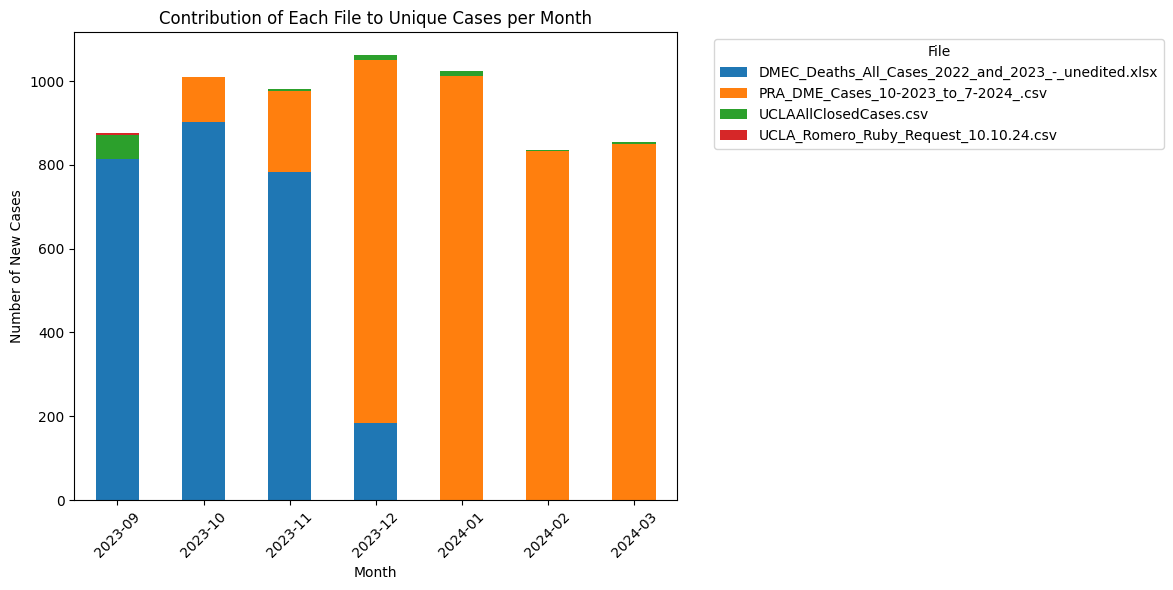

In [53]:
plot_data = prepare_plot_data(overlap_analysis)
plot_contributions(plot_data)

In [54]:
def create_overlap_analysis_table(overlap_analysis):
    rows = []
    for month, analysis in overlap_analysis.items():
        for file_name, count in analysis["case_contributions"].items():
            rows.append(
                {
                    "Month": str(month),
                    "File Name": file_name,
                    "Contribution": count,
                    "Total Unique Cases": analysis["total_unique_cases"],
                }
            )
    return pd.DataFrame(rows)


# Example: Convert the overlap analysis to a DataFrame
overlap_analysis_table = create_overlap_analysis_table(overlap_analysis)

In [57]:
overlap_analysis_table["Month"] = pd.to_datetime(overlap_analysis_table["Month"])

In [60]:
overlap_analysis_table = overlap_analysis_table.sort_values(by="Month")

In [61]:
overlap_analysis_table.to_csv("./overlap_analysis_202309_202404.csv")

In [14]:
def filter_dates_by_month(df, column, year, month):
    return df[(df[column].dt.year == year) & (df[column].dt.month == month)]


# Example usage: Filter for October 2023
filtered_dates = filter_dates_by_month(dmec_2022_2023, "DeathDate", 2023, 10)

       CaseNumber  FirstName          LastName       Age  Gender  \
66     2023-13420       KARL              KAYE  55 Years    Male   
67     2023-13647    ALFREDO            MENDEZ  37 Years    Male   
80     2023-14324    TIMOTHY            NELSON  59 Years    Male   
315    2023-13661      ROGER           PEKAREK  57 Years    Male   
316    2023-14634     ROBERT             OZAKI  67 Years    Male   
...           ...        ...               ...       ...     ...   
22656  2023-14146    ROSALIE             ZWAIN  98 Years  Female   
22658  2023-13267      MARIA             LOPEZ  68 Years  Female   
22668  2023-14067  OLADIPUPO          FASHAKIN  53 Years    Male   
22674  2023-14132      MARIO          SANTIAGO  60 Years    Male   
22780  2023-13917       IVAN  HERRERA GRACIANO  46 Years    Male   

                  Race                 DeathPlace  \
66     White/Caucasian                   Sidewalk   
67     Hispanic/Latino  Lot in front of residence   
80     White/Caucasian  

In [16]:
dmec_2022_2023

,CaseNumber,FirstName,LastName,Age,Gender,Race,DeathPlace,DeathAdress,DeathCity,DeathZip,...,EventZip,DeathDate,DeathTime,Cause A,Cause B,Cause C,ResidenceType,ExperiencingHomelessness,HowInjuryOccurred,Mode
0,2023-00489,SAUL,MARTINEZ,27 Years,MALE,HISPANIC/LATIN AMERICAN,TRAIN STATION PLATFORM,7TH STREET AT FLOWER STREET,LOS ANGELES,90017,...,NaN,2023-01-12,08:51:00,ALCOHOL INTOXICATION,NaN,NaN,APARTMENT,NaN,INGESTION OF ALCOHOL.,ACCIDENT
1,2023-09905,WILLIAM,CANOX ARMIRA,20 Years,Male,Hispanic/Latino,Vehicle,1912 Dracena Drive,Los Angeles,90027,...,90027,2023-08-01,14:50:00,ASPHYXIA,NaN,NaN,Residence,NaN,PLASTIC BAG OVER HEAD ATTACHED TO NITROGEN TANK,SUICIDE
2,2022-11407,MARCO,BULLO,14 Years,MALE,ASIAN,VEHICLE,MULHOLLAND DRIVE AND VALMAR ROAD,WOODLAND HILLS,91364,...,91364,2022-11-01,21:11:00,BLUNT HEAD TRAUMA AND THERMAL INJURIES,NaN,NaN,HOME,NaN,"AUTO VS. AUTO, WITH VEHICLE FIRE",Accident
3,2022-03777,LINDSEY,BANNER MCLAURIN,23 Years,MALE,CAUCASIAN,WALKWAY,SOUTH OF 15939 VICTORY BOULEVARD,LAKE BALBOA,91406,...,91406,2022-04-04,21:59:00,BRONCHOPNEUMONIA (S. PNEUMONIAE & S. AUREUS),NaN,NaN,INDIGENT - HOMELESS,1.0,DRUG INTAKE,Accident
4,2022-09923,LORENZO,SKANNAL,65 Years,MALE,BLACK,VEHICLE,722 CORY DRIVE UNIT #22,INGLEWOOD,90302,...,NaN,2022-09-18,09:15:00,COCAINE IINTOXICATION,NaN,NaN,APARTMENT,NaN,INTAKE OF THE DRUG,Accident
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22776,2022-12250,JOHNNY,WARNER,32 Years,MALE,CAUCASIAN,LAUNDROMAT,16105 VICTORY BOULEVARD,LAKE BALBOA,91406,...,NaN,2022-11-25,12:42:00,VOLVULUS OF SMALL INTESTINE,NaN,NaN,INDIGENT - HOMELESS,1.0,drug intake,ACCIDENT
22777,2022-02884,JOVANY,QUINTANA,27 Years,MALE,HISPANIC/LATIN AMERICAN,HOSPITAL,1500 E. DUARTE RD.,DUARTE,91010,...,NaN,2022-02-20,13:45:00,WIDELY DISSEMINATED PRECURSOR B-CELL ACUTE LYM...,NaN,NaN,HOME,NaN,NaN,Natural
22778,2022-10309,THELMA,CONCEPTION,86 Years,FEMALE,ASIAN,HOSPITAL,1115 SOUTH SUNSET AVENUE,WEST COVINA,91780,...,NaN,2022-09-28,09:52:00,NaN,NaN,NaN,Residence,NaN,NaN,NaN
22779,2022-01802,MARGIE,GARCIA,90 Years,FEMALE,Hispanic/Latino,HOSPITAL,1600W AVE J,LANCASTER,93534,...,NaN,2022-02-10,16:27:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
